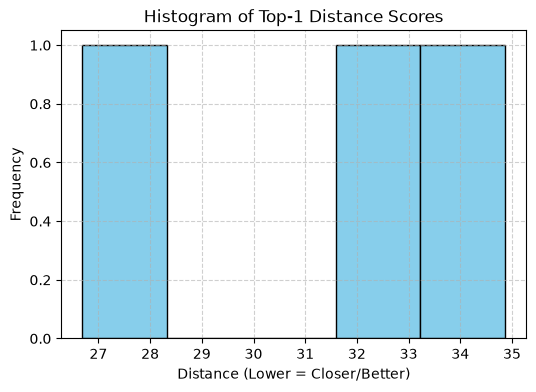

In [4]:
import matplotlib.pyplot as plt

top1_distances = []

for item in eval_dataset:
    _, distances = retrieve_top_k(item["query"], k=1)
    top1_distances.append(distances[0])

plt.figure(figsize=(6, 4))
plt.hist(top1_distances, bins=5, color='skyblue', edgecolor='black')
plt.title("Histogram of Top-1 Distance Scores")
plt.xlabel("Distance (Lower = Closer/Better)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
precision_list = []
recall_list = []
k = 3

for item in eval_dataset:
    query = item["query"]
    true_relevant = set(item["relevant_chunks"])
    
    # ดึงค่า Top-3 จากระบบ RAG
    retrieved_indices, _ = retrieve_top_k(query, k=k)
    retrieved_set = set(retrieved_indices)
    
    # หาจุดตัด (Intersection)
    intersection = retrieved_set.intersection(true_relevant)
    
    # คำนวณ Metric
    precision_at_3 = len(intersection) / k
    precision_list.append(precision_at_3)
    
    recall_at_3 = len(intersection) / len(true_relevant) if len(true_relevant) > 0 else 0
    recall_list.append(recall_at_3)
    
    print(f"คำถาม: {query}")
    print(f" - Retrieved indices: {list(retrieved_set)}")
    print(f" - True relevant: {list(true_relevant)}")
    print(f" - Precision@3: {precision_at_3:.2f} | Recall@3: {recall_at_3:.2f}\n")

# หาค่าเฉลี่ยภาพรวม
mean_precision = np.mean(precision_list)
mean_recall = np.mean(recall_list)

print("="*40)
print(f"ค่าเฉลี่ยภาพรวม (Average Metrics):")
print(f" Mean Precision@3 : {mean_precision:.2f}")
print(f" Mean Recall@3    : {mean_recall:.2f}")
print("="*40)

คำถาม: เมนูซิกเนเจอร์ของร้านคืออะไร ราคาเท่าไหร่?
 - Retrieved indices: [np.int64(0), np.int64(-1)]
 - True relevant: [0, 1]
 - Precision@3: 0.33 | Recall@3: 0.50

คำถาม: มีเมนูนมสดอะไรบ้างที่แนะนำ?
 - Retrieved indices: [np.int64(0), np.int64(-1)]
 - True relevant: [2]
 - Precision@3: 0.00 | Recall@3: 0.00

คำถาม: ร้านเปิดกี่โมงและตั้งอยู่ที่ไหน?
 - Retrieved indices: [np.int64(0), np.int64(-1)]
 - True relevant: [3]
 - Precision@3: 0.00 | Recall@3: 0.00

ค่าเฉลี่ยภาพรวม (Average Metrics):
 Mean Precision@3 : 0.11
 Mean Recall@3    : 0.17


In [2]:
# ตัวอย่างชุดทดสอบ Ground Truth (ปรับเปลี่ยนดัชนี index ให้ตรงกับข้อความใน menu_kb.md ของคุณ)
eval_dataset = [
    {
        "query": "เมนูซิกเนเจอร์ของร้านคืออะไร ราคาเท่าไหร่?",
        "relevant_chunks": [0, 1] 
    },
    {
        "query": "มีเมนูนมสดอะไรบ้างที่แนะนำ?",
        "relevant_chunks": [2] 
    },
    {
        "query": "ร้านเปิดกี่โมงและตั้งอยู่ที่ไหน?",
        "relevant_chunks": [3] 
    }
]

print(f"กำหนดชุดทดสอบสำเร็จ: ทั้งหมด {len(eval_dataset)} ข้อ")

กำหนดชุดทดสอบสำเร็จ: ทั้งหมด 3 ข้อ


In [1]:
import os
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

# 1. โหลด Knowledge Base จากไฟล์ menu_kb.md
if os.path.exists("menu_kb.md"):
    with open("menu_kb.md", "r", encoding="utf-8") as f:
        text = f.read()
    # ตัดแบ่ง Chunk ตามย่อหน้าว่าง
    chunks = [chunk.strip() for chunk in text.split("\n\n") if chunk.strip()]
else:
    chunks = ["ไม่พบไฟล์ข้อมูล menu_kb.md"]

print(f"โหลดข้อมูลสำเร็จ: ทั้งหมด {len(chunks)} Chunks")

# 2. สร้าง Embedding และ FAISS Index
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings = model.encode(chunks, convert_to_numpy=True)
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)

# ฟังก์ชันช่วยค้นหา Top-K
def retrieve_top_k(query, k=3):
    q_vector = model.encode([query], convert_to_numpy=True)
    distances, indices = index.search(q_vector, k)
    return indices[0], distances[0]

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


โหลดข้อมูลสำเร็จ: ทั้งหมด 1 Chunks


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 897.80it/s]
